In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
df.iloc[:, :2]

,User ID,Gender
0,15624510,Male
1,15810944,Male
2,15668575,Female
3,15603246,Female
4,15804002,Male
...,...,...
395,15691863,Female
396,15706071,Male
397,15654296,Female
398,15755018,Male


In [7]:
df.sample(2)

,User ID,Gender,Age,EstimatedSalary,Purchased
286,15631070,Female,37,62000,0
347,15768151,Female,54,108000,1


In [8]:
df['Gender'] = df['Gender'].map({
    'Male' : 1,
    'Female' : 0
})

In [9]:
df.dtypes

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
Purchased          int64
dtype: object

# Train test split

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1), df['Purchased'], test_size=0.25, random_state=42)

In [11]:
X_train.shape

(300, 4)

In [12]:
X_test.shape

(100, 4)

In [13]:
y_train.shape, y_test.shape

((300,), (100,))

In [14]:
X_train.dtypes

User ID            int64
Gender             int64
Age                int64
EstimatedSalary    int64
dtype: object

# StandardScaler

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

sc.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [16]:
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

In [17]:
sc.mean_

array([1.56888649e+07, 4.93333333e-01, 3.77266667e+01, 6.99000000e+04])

In [18]:
X_train

,User ID,Gender,Age,EstimatedSalary
247,15775590,0,57,122000
110,15665416,0,39,71000
16,15733883,1,47,25000
66,15679760,1,24,19000
153,15619087,0,36,50000
...,...,...,...,...
71,15726358,0,24,27000
106,15706185,0,26,35000
270,15680752,0,43,133000
348,15579212,1,39,77000


In [19]:
X_train_scaled

array([[ 1.19633572, -0.98675438,  1.8925893 ,  1.52189404],
       [-0.32346821, -0.98675438,  0.1250379 ,  0.03213212],
       [ 0.62100522,  1.01342342,  0.9106163 , -1.31157471],
       ...,
       [-0.11191454, -0.98675438,  0.5178271 ,  1.84321524],
       [-1.51261608,  1.01342342,  0.1250379 ,  0.20739823],
       [-1.43904959, -0.98675438, -0.56234321,  0.47029739]],
      shape=(300, 4))

In [20]:
# Convert scaled NumPy arrays back into DataFrames
# and restore the original column names for better readability

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [21]:
# Generate descriptive statistics (count, mean, std, min, quartiles, max)
# and round all values to 1 decimal place for cleaner and more readable output
np.round(X_train.describe(), 1)

,User ID,Gender,Age,EstimatedSalary
count,300.0,300.0,300.0,300.0
mean,15688864.9,0.5,37.7,69900.0
std,72613.4,0.5,10.2,34290.9
min,15569641.0,0.0,18.0,15000.0
25%,15622558.2,0.0,30.0,43000.0
50%,15689969.5,0.0,37.0,70500.0
75%,15749192.8,1.0,45.0,88000.0
max,15815236.0,1.0,60.0,150000.0


In [22]:
np.round(X_train_scaled.describe(), 1)

,User ID,Gender,Age,EstimatedSalary
count,300.0,300.0,300.0,300.0
mean,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0
min,-1.6,-1.0,-1.9,-1.6
25%,-0.9,-1.0,-0.8,-0.8
50%,0.0,-1.0,-0.1,0.0
75%,0.8,1.0,0.7,0.5
max,1.7,1.0,2.2,2.3


# Effect of Scaling

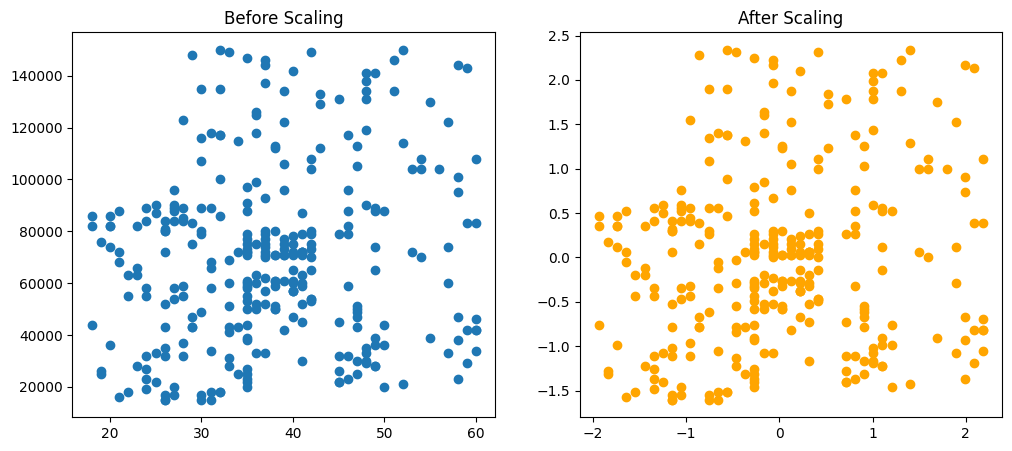

In [23]:
# Create a figure (main canvas) with 2 subplots arranged side-by-side
# ncols=2 -> creates 2 columns of plots
# figsize=(12,5) -> sets figure width to 12 inches and height to 5 inches
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='orange')
ax2.set_title("After Scaling")
plt.show()

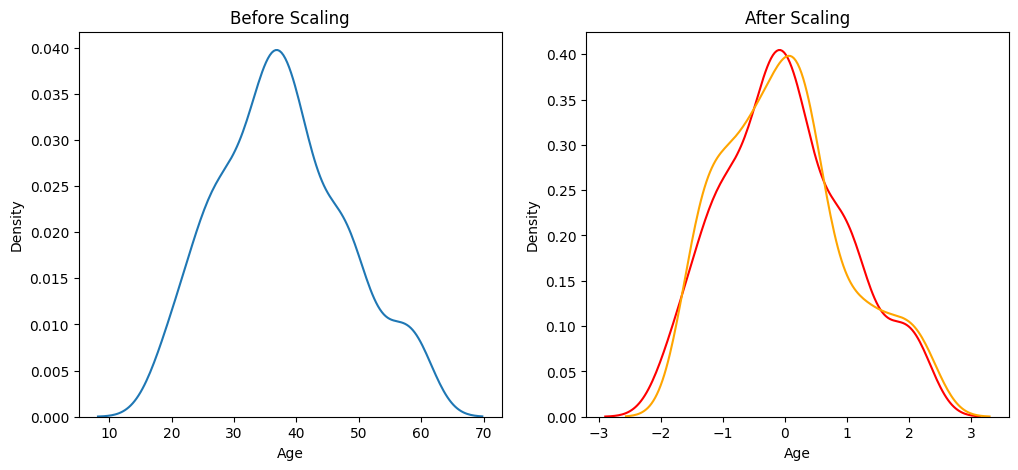

In [24]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)

ax2.set_title("After Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2, color='red')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2, color='orange')
plt.show()

# Comparison of Distributions

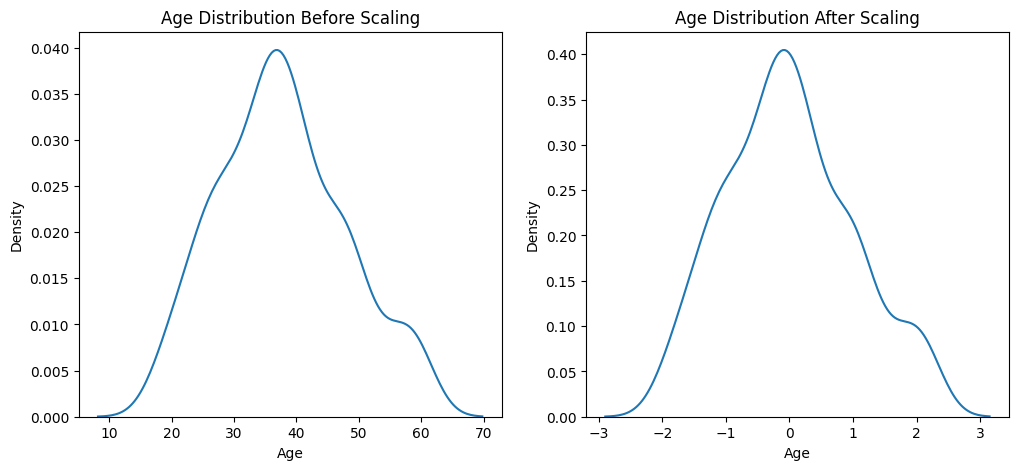

In [25]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(X_train['Age'], ax=ax1)

ax2.set_title("Age Distribution After Scaling")
sns.kdeplot(X_train_scaled['Age'], ax=ax2)

plt.show()

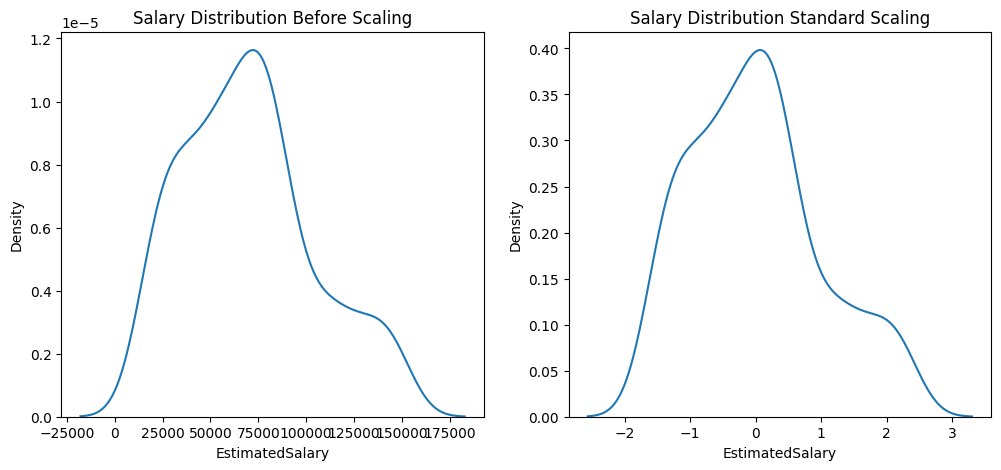

In [26]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Salary Distribution Before Scaling')
sns.kdeplot(X_train['EstimatedSalary'], ax=ax1)

# after scaling
ax2.set_title('Salary Distribution Standard Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()

# Why scaling is important?

In [27]:
from sklearn.linear_model import LogisticRegression

In [28]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [29]:
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [30]:
lr_scaled.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [32]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
print("Accuracy before scaling:", accuracy_score(y_test, y_pred))
print("Accuracy after scaling:", accuracy_score(y_test, y_pred_scaled))

Accuracy before scaling: 0.88
Accuracy after scaling: 0.88


In [37]:
from sklearn.tree import DecisionTreeClassifier

In [39]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [40]:
dt.fit(X_train, y_train)
dt_scaled.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [42]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [43]:
print("Actual",accuracy_score(y_test,y_pred))
print("Scaled",accuracy_score(y_test,y_pred_scaled))

Actual 0.87
Scaled 0.87


In [44]:
df.describe()

,User ID,Gender,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000,400.000000
mean,1.569154e+07,0.490000,37.655000,69742.500000,0.357500
std,7.165832e+04,0.500526,10.482877,34096.960282,0.479864
min,1.556669e+07,0.000000,18.000000,15000.000000,0.000000
25%,1.562676e+07,0.000000,29.750000,43000.000000,0.000000
50%,1.569434e+07,0.000000,37.000000,70000.000000,0.000000
75%,1.575036e+07,1.000000,46.000000,88000.000000,1.000000
max,1.581524e+07,1.000000,60.000000,150000.000000,1.000000


# Effect of Outlier

In [49]:
new_rows = pd.DataFrame({
    'Age': [5, 90, 95],
    'EstimatedSalary':[1000,250000,350000],
    'Purchased':[0,1,1]
})

df = pd.concat([df, new_rows], ignore_index=True)

In [50]:
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510.0,1.0,19,19000,0
1,15810944.0,1.0,35,20000,0
2,15668575.0,0.0,26,43000,0
3,15603246.0,0.0,27,57000,0
4,15804002.0,1.0,19,76000,0
...,...,...,...,...,...
398,15755018.0,1.0,36,33000,0
399,15594041.0,0.0,49,36000,1
400,NaN,NaN,5,1000,0
401,NaN,NaN,90,250000,1


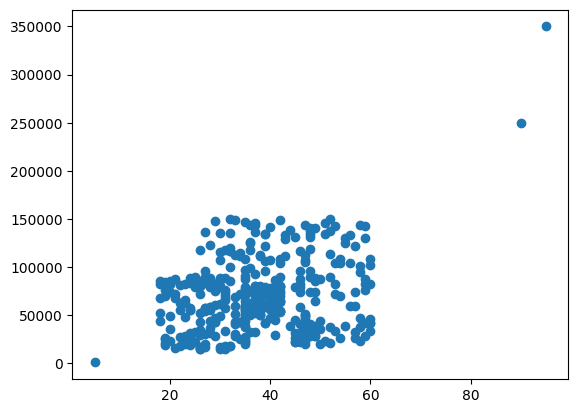

In [51]:
plt.scatter(df['Age'], df['EstimatedSalary'])

In [52]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df.drop('Purchased', axis=1),
                                                    df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

X_train.shape, X_test.shape

((282, 4), (121, 4))

In [55]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

sc.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [56]:
X_train_scaled = sc.transform(X_train)
X_test_scaled = sc.transform(X_test)

In [58]:
# Convert scaled training data back into a DataFrame
# and keep the original column names
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

# Convert scaled test data back into a DataFrame
# and keep the original column names
X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

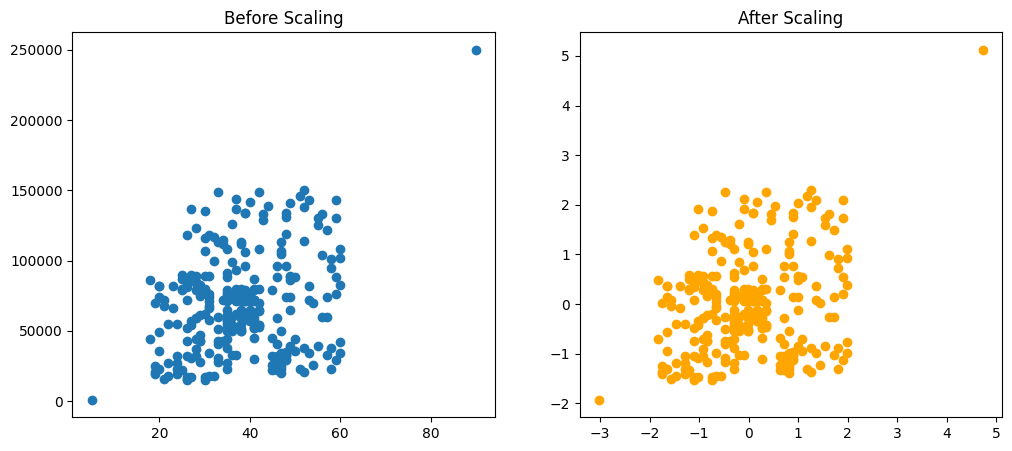

In [59]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.set_title("Before Scaling")
ax1.scatter(X_train['Age'], X_train['EstimatedSalary'])

ax2.set_title("After Scaling")
ax2.scatter(X_train_scaled['Age'], X_train_scaled['EstimatedSalary'], color='orange')
plt.show()